In [9]:
from PPOClip import PPO_Clip
from ValueNet import ValueNet
from PolicyNet import PolicyNet
import matplotlib.pyplot as plt 
import torch
import flappy_bird_gymnasium
import gymnasium

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")



Using device: mps


## Environment

In [ ]:

env = gymnasium.make("FlappyBird-v0", use_lidar=False)
print(f"Action Dim: {env.action_space.n}")
print(f"Obs Dim: {env.observation_space}")

Action Dim: 2
Obs Dim: Box(-1.0, 1.0, (12,), float64)


/Users/mateocostantini/Library/Python/3.9/lib/python/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [4]:
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)



In [5]:
hiperparams = {
    "epochs": 30, 
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.2, 
    "lr": 0.001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95
}

/Users/mateocostantini/Documents/AA_Udesa/4año/RL/TP Final/TPF-RL-LopezVilaclara-Costantini-Lewit/PPOClip.py:60: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  values = self.value_net(torch.FloatTensor(states)).detach().squeeze().numpy()


Epoch 10/30 completed.
Epoch 20/30 completed.
Epoch 30/30 completed.


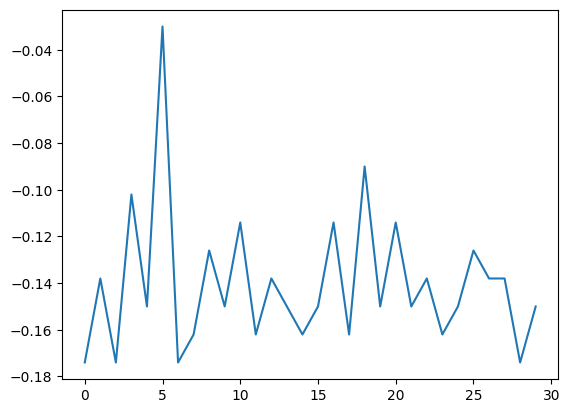

In [6]:
PPO = PPO_Clip(hiperparams["epochs"], hiperparams["batch_size"], hiperparams["policy_net"], hiperparams["value_net"], hiperparams["clip_param"], hiperparams["lr"], hiperparams["discount_factor"], hiperparams["gae_lambda"])
rewards = PPO.train(env)
plt.plot(rewards)
plt.show()

In [7]:
env = gymnasium.make("FlappyBird-v0", render_mode = "human", use_lidar=False)

PPO.evaluate(env)

[0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 0.1,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -1]